In [1]:
import sklearn
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import proteinmlutils.featurizer as protfeat

In [2]:
protein_df=pd.read_csv("../data/A0A2Z5U3Z0_9INFA_Doud_2016.csv").sample(n=5000, random_state=42)
protein_df.rename(columns={"mutated_sequence": "protein_sequence"}, inplace=True)
protein_df

,mutant,protein_sequence,DMS_score,DMS_score_bin
10308,V544G,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.613682,0
6705,E354I,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.864511,0
304,D18T,MKAKLLVLLYAFVATDATTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.774094,0
9142,F483V,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.423986,0
10592,L559I,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.298089,0
...,...,...,...,...
9405,N497E,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,0.417371,1
4423,P234D,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-3.178611,0
1243,L67N,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.722072,0
8657,N457H,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.809659,0


In [3]:
#check if the protein_sequence column has unique values
assert len(protein_df['protein_sequence'].unique()) == len(protein_df), "The 'protein_sequence' column does not have unique values"


In [4]:
protein_df['protein_sequence'].str.len().describe() # Check the maximum length of the protein sequences

count    5000.0
mean      565.0
std         0.0
min       565.0
25%       565.0
50%       565.0
75%       565.0
max       565.0
Name: protein_sequence, dtype: float64

In [5]:
import proteinmlutils.charge_analysis as charge_analysis
protein_df["negative_charge"]=protein_df["protein_sequence"].apply(lambda x: charge_analysis.total_charge_fn(x, type="negative_charge"))
protein_df["positive_charge"]=protein_df["protein_sequence"].apply(lambda x: charge_analysis.total_charge_fn(x, type="positive_charge"))
protein_df["net_charge"]=protein_df["positive_charge"]+protein_df["negative_charge"]


(array([ 485.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0., 4024.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,  491.]),
 array([54.  , 54.04, 54.08, 54.12, 54.16, 54.2 , 54.24, 54.28, 54.32,
        54.36, 54.4 , 54.44, 54.48, 54.52, 54.56, 54.6 , 54.64, 54.68,
        54.72, 54.76, 54.8 , 54.84, 54.88, 54.92, 54.96, 55.  , 55.04,
        55.08, 55.12, 55.16, 55.2 , 55.24, 55.28, 55.32, 55.36, 55.4 ,
        55.44, 55.48, 55.52, 55.56, 55.6 , 55.64, 55.68, 55.72, 55.76,
        55.8 , 55.84, 55.88, 55.92, 55.96, 56.  ]),
 <BarContainer object of 50 artists>)

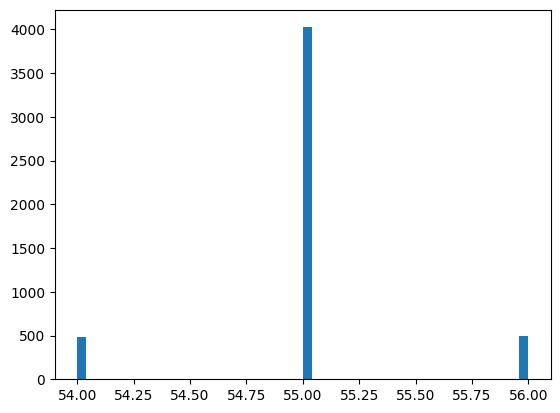

In [6]:
plt.hist(protein_df["positive_charge"], bins=50)

(array([  51.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,  826.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0., 3204.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,  872.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,   47.]),
 array([-6.  , -5.92, -5.84, -5.76, -5.68, -5.6 , -5.52, -5.44, -5.36,
        -5.28, -5.2 , -5.12, -5.04, -4.96, -4.88, -4.8 , -4.72, -4.64,
        -4.56, -4.48, -4.4 , -4.32, -4.24, -4.16, -4.08, -4.  , -3.92,
        -3.84, -3.76, -3.68, -3.6 , -3.52, -3.44, -3.36, -3.28, -3.2 ,
        -3.12, -3.04, -2.96, -2.88, -2.8 , -2.72, -2.64, -2.56, -2.48,
        -2.4 , -2.32, -2.24, -2.16, -2.08, -2.  ]),
 <BarContainer object of 50 artists>)

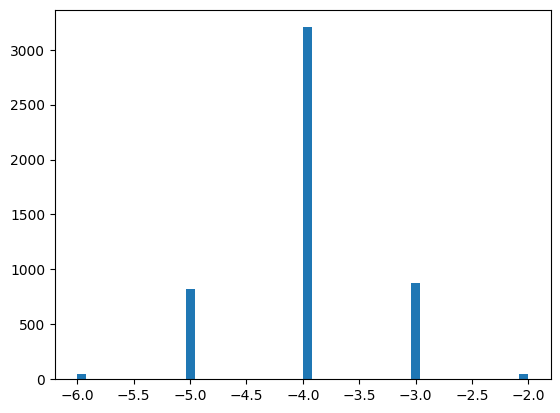

In [7]:
plt.hist(protein_df["net_charge"], bins=50)

In [8]:
max_length = int(protein_df['protein_sequence'].str.len().max())  # Get the maximum length of the sequences
sequence_arr = protein_df['protein_sequence'].tolist()
y_arr = protein_df['DMS_score'].tolist()


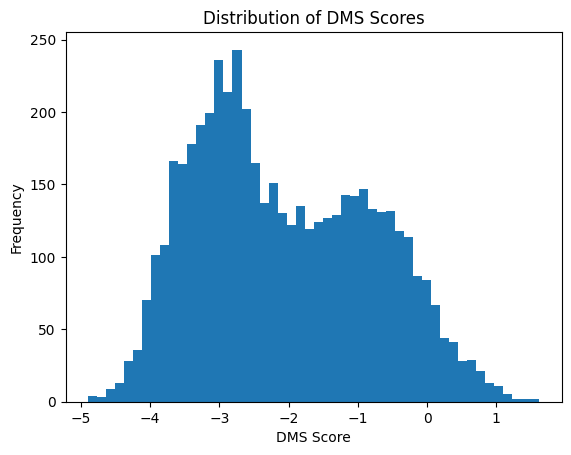

In [9]:
plt.hist(protein_df['DMS_score'], bins=50)
plt.xlabel('DMS Score')
plt.ylabel('Frequency')
plt.title('Distribution of DMS Scores')
plt.show()

(array([4296.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         704.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

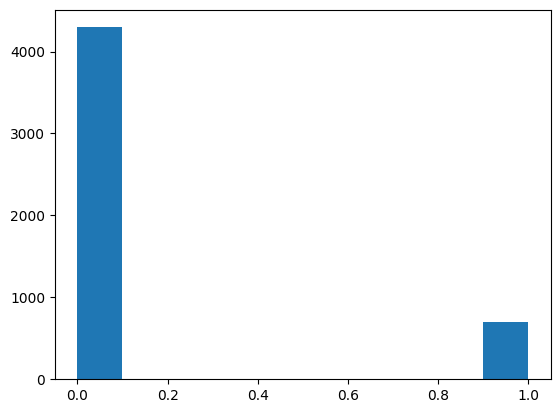

In [10]:
y_discretize_arr=np.digitize(y_arr,bins=[-0.5])
plt.hist(y_discretize_arr)

In [11]:

X_arr=protfeat.protein_one_hot_encoder(sequence_arr, max_length=max_length, flatten=True)
print(X_arr.shape)  # Check the shape of the one-hot encoded array

(5000, 11865)


In [12]:
assert X_arr.shape == (len(protein_df), max_length * 21), "The shape of the one-hot encoded array does not match the expected shape"

In [13]:
embedding_dim = 5  # Set the embedding dimension
embedding_arr, embedding_weight=protfeat.protein_embedding_generator(sequence_arr, max_length, embedding_dim=embedding_dim, flatten=True)

In [14]:
assert embedding_arr.shape == (len(protein_df), max_length * embedding_dim), "The shape of the one-hot encoded array does not match the expected shape"

In [15]:
sequence_data=protein_df["protein_sequence"]

In [16]:
#from proteinmlutils.ML_trainer import classifier_model_trainer
from proteinmlutils.data_stratifier import data_train_vs_test_splitting
sequence_arr=protein_df["protein_sequence"].tolist()
df=data_train_vs_test_splitting(X_arr, y_discretize_arr, sequence_arr, test_size=0.5)




Training+validation sample size: 2500
Test sample size: 2500


In [17]:
df.rename(columns={"sequence":"protein_sequence"}, inplace=True)
protein_df_combined=protein_df.join(df.set_index("protein_sequence"), on="protein_sequence", how="left")


In [19]:
#convert it to 2D numpy array
X_train = protein_df_combined[protein_df_combined["Train_vs_Test"]=="Train"]["X"]
X_train = np.array(X_train.tolist())
X_test=protein_df_combined[protein_df_combined["Train_vs_Test"]=="Test"]["X"]
X_test = np.array(X_test.tolist())
y_train=protein_df_combined[protein_df_combined["Train_vs_Test"]=="Train"]["y"].to_numpy()
y_test=protein_df_combined[protein_df_combined["Train_vs_Test"]=="Test"]["y"].to_numpy()


In [20]:
from proteinmlutils import model_trainer
clf_trainer = model_trainer.classifier_model_trainer(X_train, y_train)

rf_classifier, results_df = clf_trainer.RandomForestClassifier_trainer(training_mode="default")

y_pred = rf_classifier.predict(X_test)

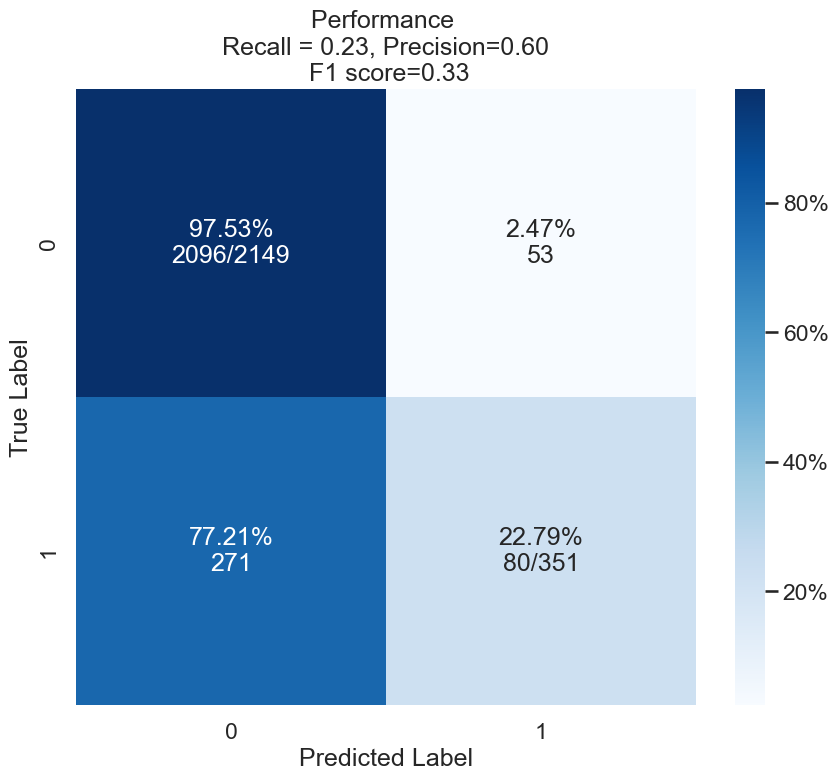

In [21]:
from proteinmlutils import model_eval
folder_name = "../output/DMS_Random_Forest_classifier_results"
model_eval.save_classification_report(y_test, y_pred, folder_name)
model_eval.save_confusion_matrix(y_test,y_pred, foldername=folder_name, labels=[0,1])

In [22]:
## Cross-validation
kwargs = {}
kwargs['scoring'] = ["f1", "precision", "recall", "accuracy"]
kwargs['n_iter'] = 5
kwargs['primary_scoring'] = 'f1'


clf_trainer = model_trainer.classifier_model_trainer(X_train, y_train, **kwargs)
rf_classifier, results_df = clf_trainer.RandomForestClassifier_trainer(training_mode="CrossVal")

y_pred = rf_classifier.predict(X_test)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

[CV] END bootstrap=True, max_depth=20, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   1.5s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   1.3s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   1.7s


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END bootstrap=False, max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   1.8s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   1.8s


...

[CV] END bootstrap=True, max_depth=20, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   1.0s


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

[CV] END bootstrap=True, max_depth=5, min_samples_leaf=3, min_samples_split=5, n_estimators=200; total time=   1.5s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=3, min_samples_split=5, n_estimators=200; total time=   1.3s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=3, min_samples_split=5, n_estimators=200; total time=   1.3s


/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/protein_ml_utils/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

[CV] END bootstrap=False, max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   6.5s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   6.6s
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   6.6s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  15.8s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  15.9s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  16.0s
Best parameters found:  {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': True}
Score on training: Recall= 1.0 Precision= 1.0 F1 score= 1.0
